# Clase 8 · Series Temporales II — Live Coding
## Torneo de Forecasting — `ventas_mensuales.csv`

Diplomado de Python y Análisis de Datos · Universidad Marista

**Cómo usar este notebook:**
Cada celda de código está **comentada línea por línea**. Durante la clase,
ve descomentando (quitando el `# ` al inicio de cada línea) según avancemos
en la presentación. Las celdas de texto (Markdown) indican en qué paso de
la presentación estamos.

Dataset: 60 meses de historia de ventas mensuales (`fecha`, `ventas`,
`promociones`, `unidades`).


## Paso 0 — Librerías
Descomentar al iniciar la sesión.

In [121]:
# Paso 0: Librerías necesarias para todo el notebook
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Paso 1 — Cargar los datos
(Correspondiente a *Paso 1: cargar* de la presentación)

In [136]:
# Paso 1: cargar el csv y preparar el índice temporal
#
df = pd.read_csv("../data/ventas_mensuales.csv")
#
df["fecha"] = pd.to_datetime(df["fecha"])
#
df = df.sort_values("fecha")
#
df = df.set_index("fecha")
#
print(df.shape)
df.head()

(60, 3)


,ventas,promociones,unidades
fecha,,,
2021-09-01,"7,567.00",0,165
2021-10-01,"7,383.00",1,150
2021-11-01,"8,005.00",0,176
2021-12-01,"8,342.00",0,167
2022-01-01,"8,001.00",0,166


## Paso 2 — Visualizar la serie
(*Paso 2: visualizar*). Antes de modelar, debemos comprender la serie.

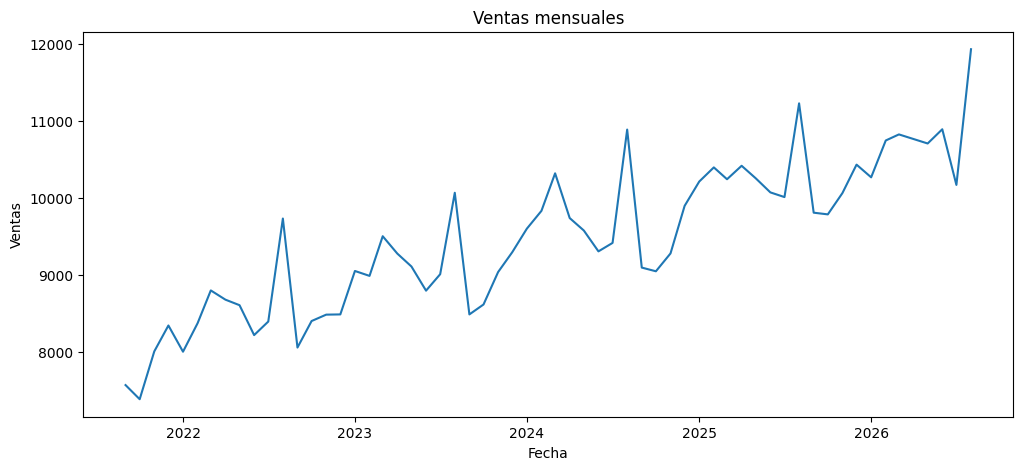

In [137]:
# Paso 2: graficar la serie completa
#
plt.figure(figsize=(12, 5))
#
plt.plot(df.index, df["ventas"])
#
plt.title("Ventas mensuales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
#
plt.show()

### Pregunta para el grupo
- ¿La serie muestra tendencia?
- ¿Hay estacionalidad visible (patrón que se repite cada 12 meses)?
- ¿Hay algún valor atípico?

## Paso 3 — Train / Test temporal
(*Paso 3: Train/Test*). Reservamos los últimos 12 meses como si fueran el futuro.

In [138]:
# Paso 3: dividir train/test respetando el orden temporal
#
train = df.iloc[:-12].copy()
#
test = df.iloc[-12:].copy()
#
print("Train:", train.shape)
print("Test:", test.shape)
#
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

Train: (48, 3)
Test: (12, 3)
2021-09-01 00:00:00 2025-08-01 00:00:00
2025-09-01 00:00:00 2026-08-01 00:00:00


## Paso 4 — Baseline: Naive Forecast
(*Paso 4: Naive*). $\hat{Y}_{t+1} = Y_t$

In [139]:
# Paso 4: Naive Forecast — repetir el último valor observado
#
ultimo = train["ventas"].iloc[-1]
#
pred_naive = [ultimo] * len(test)
#
print(pred_naive[:5])

[np.float64(11231.0), np.float64(11231.0), np.float64(11231.0), np.float64(11231.0), np.float64(11231.0)]


## Paso 5 — Seasonal Naive
(*Paso 5: Seasonal Naive*). $\hat{Y}_t = Y_{t-12}$

In [140]:
# Paso 5: Seasonal Naive — usar el mismo mes del año anterior
#
pred_seasonal = train["ventas"].iloc[-12:].values
#
print(pred_seasonal)

[ 9095.  9047.  9279.  9898. 10214. 10398. 10244. 10419. 10256. 10073.
 10012. 11231.]


### Extra — Media móvil (opcional, referencia adicional)

In [141]:
# Extra: pronóstico con el promedio de los últimos 3 meses
#
promedio_reciente = train["ventas"].tail(3).mean()
#
pred_ma = [promedio_reciente] * len(test)
#
print(promedio_reciente)

10438.666666666666


## Paso 6 — Simple Exponential Smoothing (SES)
(*Paso 6: SES*).

In [142]:
# Paso 6: Suavizamiento exponencial simple
#
modelo_ses = SimpleExpSmoothing(train["ventas"])
#
ajuste_ses = modelo_ses.fit()
#
pred_ses = ajuste_ses.forecast(len(test))
#
print(pred_ses)

2025-09-01   10,526.83
2025-10-01   10,526.83
2025-11-01   10,526.83
2025-12-01   10,526.83
2026-01-01   10,526.83
2026-02-01   10,526.83
2026-03-01   10,526.83
2026-04-01   10,526.83
2026-05-01   10,526.83
2026-06-01   10,526.83
2026-07-01   10,526.83
2026-08-01   10,526.83
Freq: MS, dtype: float64


c:\Users\Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Paso 7 — Holt (nivel + tendencia)
(*Paso 7: Holt*).

In [143]:
# Paso 7: Holt — nivel + tendencia
#
modelo_holt = Holt(train["ventas"])
#
ajuste_holt = modelo_holt.fit()
#
pred_holt = ajuste_holt.forecast(len(test))
#
print(pred_holt)

2025-09-01   10,747.35
2025-10-01   10,835.96
2025-11-01   10,924.58
2025-12-01   11,013.20
2026-01-01   11,101.82
2026-02-01   11,190.44
2026-03-01   11,279.05
2026-04-01   11,367.67
2026-05-01   11,456.29
2026-06-01   11,544.91
2026-07-01   11,633.53
2026-08-01   11,722.14
Freq: MS, dtype: float64


c:\Users\Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Paso 8 — Holt-Winters (nivel + tendencia + estacionalidad)
(*Paso 8: Holt-Winters*).

In [150]:
# Paso 8: Holt-Winters aditivo, estacionalidad de 12 meses
#
modelo_hw = ExponentialSmoothing(
    train["ventas"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)
#
ajuste_hw = modelo_hw.fit()
#
pred_hw = ajuste_hw.forecast(len(test))
#
print(pred_hw)

c:\Users\Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2025-09-01    9,698.79
2025-10-01    9,759.29
2025-11-01   10,099.05
2025-12-01   10,403.29
2026-01-01   10,614.79
2026-02-01   10,795.54
2026-03-01   11,114.54
2026-04-01   10,926.29
2026-05-01   10,785.04
2026-06-01   10,495.79
2026-07-01   10,605.54
2026-08-01   11,878.54
Freq: MS, dtype: float64


## Paso 9 — ARIMA básico
(*Paso 9: ARIMA*). Introducción conceptual, order=(1,1,1).

In [151]:
# Paso 9: ARIMA(1,1,1) como acercamiento introductorio
#
modelo_arima = ARIMA(train["ventas"], order=(1, 1, 1))
#
ajuste_arima = modelo_arima.fit()
#
pred_arima = ajuste_arima.forecast(steps=len(test))
#
print(pred_arima)

2025-09-01   10,751.18
2025-10-01   10,689.51
2025-11-01   10,681.58
2025-12-01   10,680.57
2026-01-01   10,680.43
2026-02-01   10,680.42
2026-03-01   10,680.42
2026-04-01   10,680.41
2026-05-01   10,680.41
2026-06-01   10,680.41
2026-07-01   10,680.41
2026-08-01   10,680.41
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Victus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Comparar modelos
Función de evaluación con MAE y RMSE.

In [152]:
# Evaluar Naive como ejemplo
#
def evaluar(real, pred):
    mae = mean_absolute_error(real, pred)
    rmse = mean_squared_error(real, pred) ** 0.5
    return mae, rmse
#
mae_naive, rmse_naive = evaluar(test["ventas"], pred_naive)
print(mae_naive, rmse_naive)

813.9166666666666 896.7047544574896


In [153]:
# Tabla comparativa del torneo (MAE, RMSE, MAPE)
#
def mape(real, pred):
    real = np.array(real)
    pred = np.array(pred)
    return np.mean(np.abs((real - pred) / real)) * 100

resultados = pd.DataFrame({
    "Modelo": [
        "Naive",
        "Seasonal Naive",
        "Media movil",
        "SES",
        "Holt",
        "Holt-Winters",
        "ARIMA"
    ],
    "MAE": [
        evaluar(test["ventas"], pred_naive)[0],
        evaluar(test["ventas"], pred_seasonal)[0],
        evaluar(test["ventas"], pred_ma)[0],
        evaluar(test["ventas"], pred_ses)[0],
        evaluar(test["ventas"], pred_holt)[0],
        evaluar(test["ventas"], pred_hw)[0],
        evaluar(test["ventas"], pred_arima)[0],
    ],
    "RMSE": [
        evaluar(test["ventas"], pred_naive)[1],
        evaluar(test["ventas"], pred_seasonal)[1],
        evaluar(test["ventas"], pred_ma)[1],
        evaluar(test["ventas"], pred_ses)[1],
        evaluar(test["ventas"], pred_holt)[1],
        evaluar(test["ventas"], pred_hw)[1],
        evaluar(test["ventas"], pred_arima)[1],
    ],
    "MAPE": [
        mape(test["ventas"], pred_naive),
        mape(test["ventas"], pred_seasonal),
        mape(test["ventas"], pred_ma),
        mape(test["ventas"], pred_ses),
        mape(test["ventas"], pred_holt),
        mape(test["ventas"], pred_hw),
        mape(test["ventas"], pred_arima),
    ],
})

resultados = resultados.sort_values("MAE")

resultados

,Modelo,MAE,RMSE,MAPE
5,Holt-Winters,167.51,224.02,1.59
3,SES,445.58,564.72,4.19
2,Media movil,445.58,572.73,4.16
6,ARIMA,452.35,593.59,4.32
1,Seasonal Naive,520.58,573.53,4.95
4,Holt,735.80,800.04,7.12
0,Naive,813.92,896.70,7.89


## Visualizar: Real vs Pronóstico
Usando el mejor modelo (ajustar la variable `pred_ganador` según el torneo).

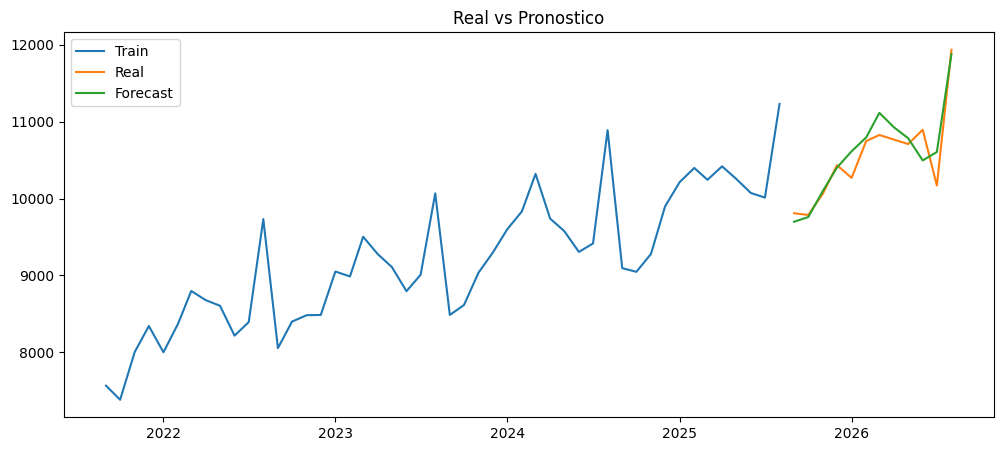

In [154]:
# Graficar train, real y pronóstico del modelo ganador
#
pred_ganador = pred_hw  # cambiar por el modelo con menor MAE
#
plt.figure(figsize=(12, 5))
#
plt.plot(train.index, train["ventas"], label="Train")
plt.plot(test.index, test["ventas"], label="Real")
plt.plot(test.index, pred_ganador, label="Forecast")
#
plt.legend()
plt.title("Real vs Pronostico")
plt.show()

## Analizar residuos
¿El modelo está sesgado? ¿Hay estructura remanente en los errores?

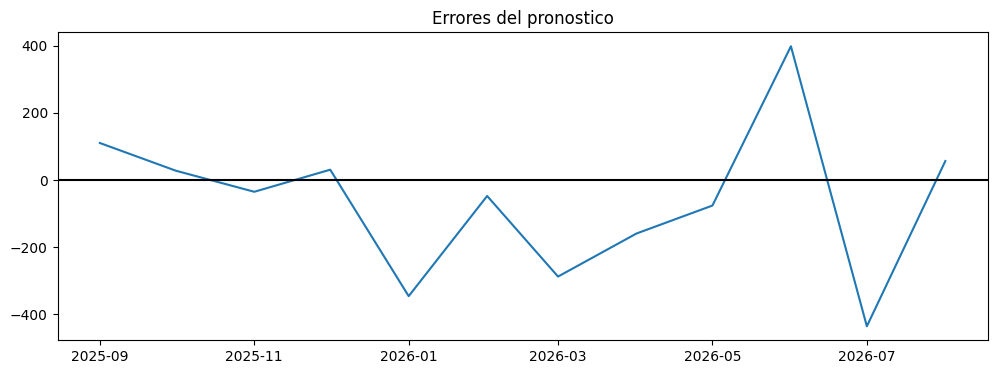

Error promedio (sesgo): -63.62533499984556


In [155]:
# Calcular y graficar los residuos del modelo ganador
#
residuos = test["ventas"] - pred_ganador
#
plt.figure(figsize=(12, 4))
plt.plot(residuos)
plt.axhline(0, color="black")
plt.title("Errores del pronostico")
plt.show()
#
print("Error promedio (sesgo):", residuos.mean())

## Cierre
- ¿Qué modelo ganó el torneo (menor MAE / RMSE)?
- ¿El baseline (Naive / Seasonal Naive) fue competitivo?
- ¿Los residuos muestran sesgo o estructura?
- Puente a la Clase 9: Introducción a Machine Learning.